# TP Structured Search

## Objectifs

Ce TP à pour objetcif de vous familliariser avec les commandes de recherche dans OpenSearch.
Vous apprendrez à :
* Effectuer des requêtes structurées sur des valeurs exactes.
* Effectuer des agrégations sur des valeurs exactes.


## Import du jeux de données 

On va travailler sur le jeux de données movies. Si ce n'est pas votre cas, c'est génial vous apprendrez tout sur les films.

Vous travaillerez sur un nouvel index `movies` que vous pourrez charger dans votre cluster avec la commande shell suivante, depuis le répertoire du TP :


Execution sous winsdows :

In [ ]:
 curl.exe -H "Content-Type: application/x-ndjson" -X PUT "https://localhost:9200/_bulk"  -ku admin:admin --data-binary "@\C:\lien_absolue_vers_votre_tp\data\movies.json"

Jetons à présent un oeil sur un de nos documents movies :

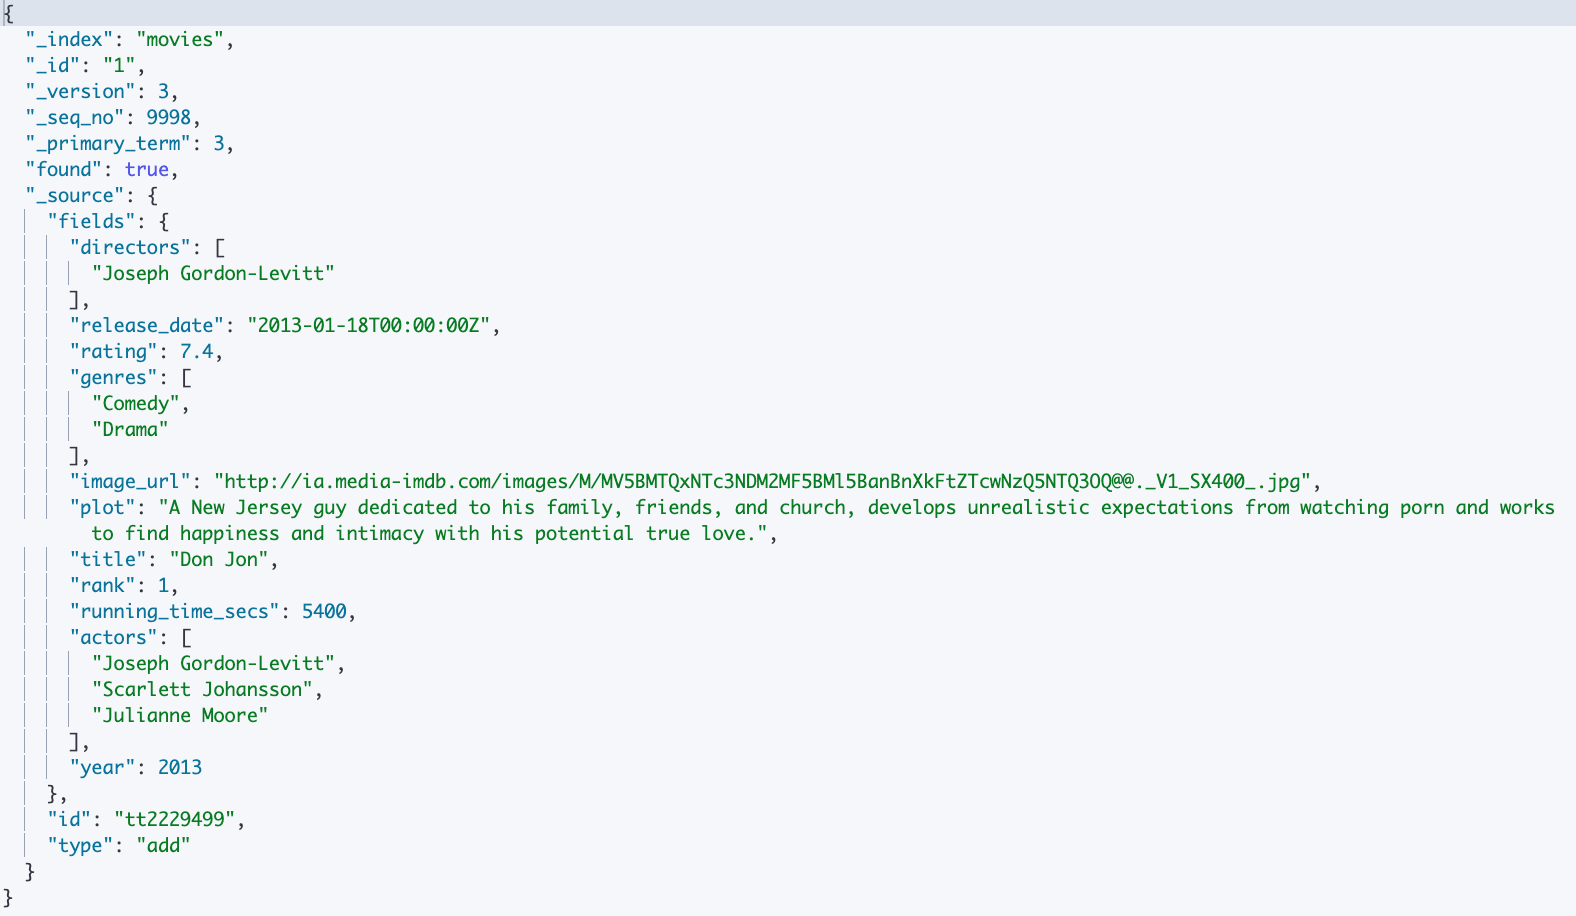

## Mes premières recherches

A partir de la documentation [ElasticSearch](https://www.elastic.co/guide/en/elasticsearch/guide/master/structured-search.html) , exprimer les requêtes suivantes :





### Rechercher le film avec le titre `Spider-Man`? 


### Rechercher les films réalisés entre le 01/05/1977 et le 31/05/1977 ?

### Rechercher les acteurs du film `Spider-Man`et les directeurs ?


```{note}
Le lien suivant vous aidera à la selection des clé à afficher.

[https://www.elastic.co/guide/en/elasticsearch/reference/current/search-fields.html#source-filtering](https://www.elastic.co/guide/en/elasticsearch/reference/current/search-fields.html#source-filtering)
```

### Trier la requête suivante par ordre décroissant de la clé `release_date`?

```{note}
Appuyez vous sur la documentation ElasticSeach 
https://www.elastic.co/guide/en/elasticsearch/reference/current/sort-search-results.html
```


Bravo, on dirait que vous avez compris le principe mais par précaution vérifions avec des requêtes un peu plus complexes ;-) 

### Rechercher les films qui n'ont pas de clé `rating` et afficher uniquement leur titre `title`?

```{note}
Le lien suivant vous aidera pour déterminer l'existence d'une clé

[https://www.elastic.co/guide/en/elasticsearch/guide/master/_dealing_with_null_values.html](https://www.elastic.co/guide/en/elasticsearch/guide/master/_dealing_with_null_values.html)

### Rechercher les films dans le top ten ayant une notation `rank` strictement supérieur à 8 ?

```{note}
La liste des résultats sera triée par ordre croissant du `rank` et décroissant par année `year`
```

GET movies/_search
{
   "sort" : [
     { "fields.rank" : "asc" },
     { "fields.year" : "desc" }
   ],
   
   "query" : {
      "bool": {
        "must": [
          {
            "range": {
              "fields.rank":{
                "lte": 10
              }
            }
          },
           {
              "range": {
              "fields.rank":{
                "gt": 8
              }
            }
          } 
        ]
      }
   }
}

### Rechercher les films dirigés par le `director` `Bryan Singer` mais qui ne sont pas genre `Adventure`?

## Les agrégations

Pour cette partie vous pourrez vous appuyer sur la documentation suivante :
    
https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations.html


### Déterminer la distribution des films par score  

```{admonition} Indice!
:class: dropdown
L'utilisation d'un histogramme semble bien adapté mais je ne vous ai rien dit ;-).

https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations-bucket-histogram-aggregation.html
```



### Déterminer à partir de la requête précédente la distribution en incluent le genre ? 

```{admonition} Indice!
:class: dropdown
C'était facile ici !
Allez je vous aide quand même, l'ajout d'une agrégation avec un sous regroupement par terms sur genres devrait faire l'affaire 
Je vous rajoute le lien si vous ne vous souvenez pas de la syntaxe ;-)

[https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations-bucket-terms-aggregation.html](https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations-bucket-terms-aggregation.html)
```


### Déterminer le mois ou il y a eu le plus de film réalisé ?   

```{admonition} Indice!
:class: dropdown
Celle-ci, elle pique les yeux ça mérite un gros coups de main.
Utilisez date_histogram comme première agrégation sur release_data avec un interval par mois , je vous file le lien 

[https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations-bucket-datehistogram-aggregation.html](https://www.elastic.co/guide/en/elasticsearch/reference/8.8/search-aggregations-bucket-datehistogram-aggregation.html)
```

```{admonition} Indice!
:class: dropdown
Pour utiliser les champs retournés par la première agrégation je vous invite à regarder l'exemple du max en lien ci-dessous :
[https://www.elastic.co/guide/en/elasticsearch/reference/current/search-aggregations-pipeline-max-bucket-aggregation.html](https://www.elastic.co/guide/en/elasticsearch/reference/current/search-aggregations-pipeline-max-bucket-aggregation.html)

Je précise que la valeur du count est référencé par _count.
```


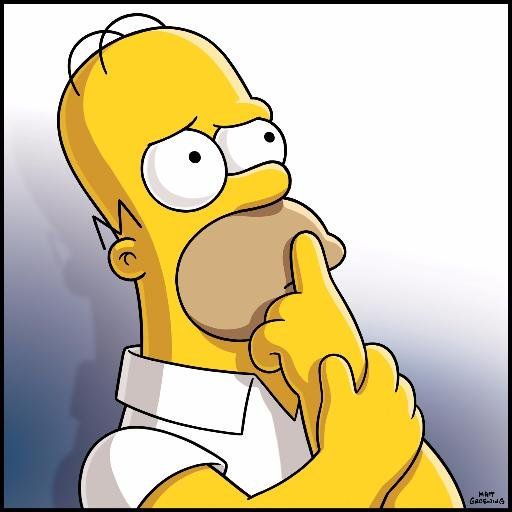

Pourquoi on fait tout ça déjà !!!
Ah oui calculer des statistiques sur nos données indexées mais il y a pas plus simple pour réaliser ces requêtes ?
On est quand même en 2023 !

Ca serait bien un outil qui nous affiche la distribution des films par notes en prenant en compte leur catégorie du genre un graphe comme celui-là :



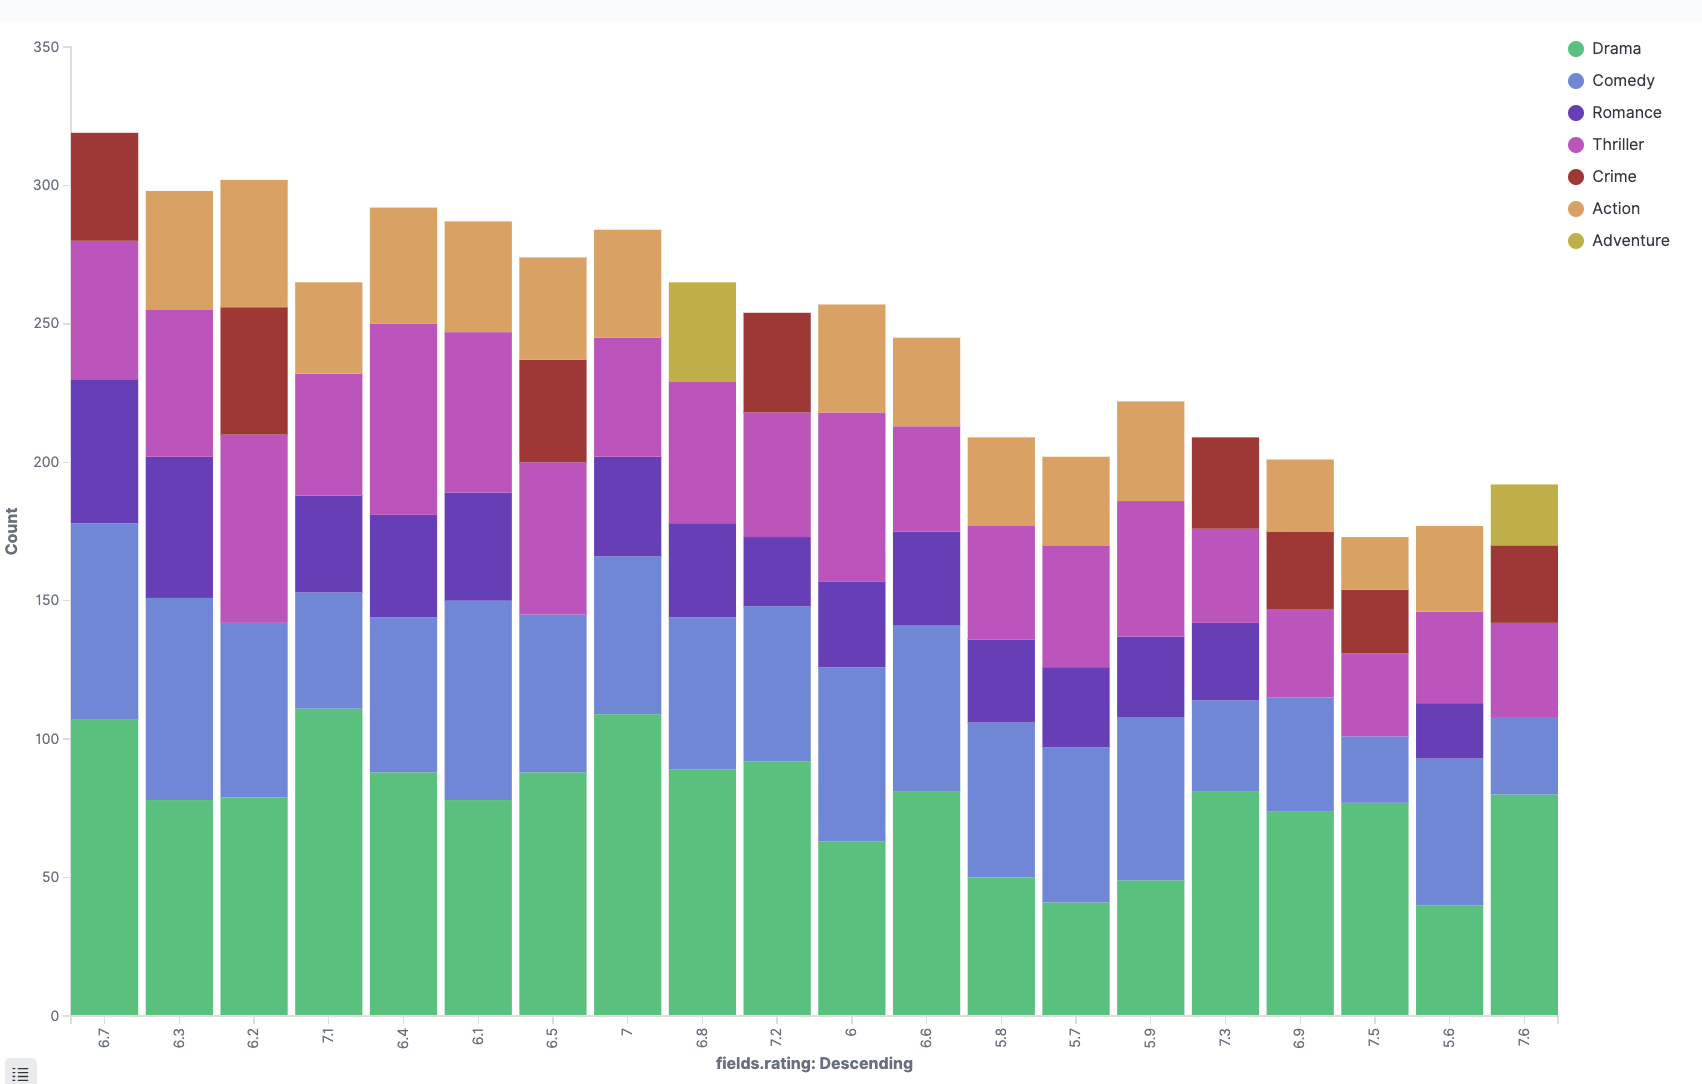

Ca serait vraiment cool mais le professeur réserve ça pour plus tard ;-).

Il aimerait aborder d'autres sujets et notamment un sujet délicat la recherche textuelle.

Clap you hands si vous êtres prêt pour la suite.
